In [1]:
# =============================================================================
# ENVIRONMENT SETUP
# Purpose: Import all libraries and configure notebook settings.
# Expected: All imports succeed and versions print cleanly.
# =============================================================================

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))
from code_library.data_preparation import load_cmapss, load_naval

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42

CMAPSS_DIR = "Data/CMaps"
NAVAL_DIR  = "Data/UCI CBM Dataset"

print("Setup complete")
print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")

Setup complete
numpy  : 1.26.4
pandas : 2.2.2


In [2]:
# =============================================================================
# DATA LOADING — CMAPSS & NAVAL
# Purpose: Load raw data from both domains into DataFrames for EDA.
# Expected: CMAPSS FD001 train ~20,631 rows x 26 cols. Naval 11,934 rows x 18 cols.
# =============================================================================

# CMAPSS — load FD001 for initial EDA (will loop all 4 subsets later)
cmapss_train, cmapss_test = load_cmapss(subset="FD001", raw_dir=CMAPSS_DIR, rul_clip=125)

# Naval — load raw (un-normalized) for EDA
naval_x, naval_y = load_naval(raw_dir=NAVAL_DIR)

print("CMAPSS FD001")
print(f"  Train shape : {cmapss_train.shape}")
print(f"  Test shape  : {cmapss_test.shape}")
print(f"  Columns     : {list(cmapss_train.columns)}")
print()
print("Naval Propulsion Plants")
print(f"  Features shape : {naval_x.shape}")
print(f"  Targets shape  : {naval_y.shape}")
print(f"  Features       : {list(naval_x.columns)}")
print(f"  Targets        : {list(naval_y.columns)}")

CMAPSS FD001
  Train shape : (20631, 21)
  Test shape  : (13096, 21)
  Columns     : ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'rul']

Naval Propulsion Plants
  Features shape : (11934, 16)
  Targets shape  : (11934, 2)
  Features       : ['lever_position', 'ship_speed', 'gt_shaft_torque', 'gt_rate_of_revolutions', 'gas_generator_rate_of_revolutions', 'starboard_propeller_torque', 'port_propeller_torque', 'hp_turbine_exit_temperature', 'gt_compressor_inlet_air_temperature', 'gt_compressor_outlet_air_temperature', 'hp_turbine_exit_pressure', 'gt_compressor_inlet_air_pressure', 'gt_compressor_outlet_air_pressure', 'gt_exhaust_gas_pressure', 'turbine_injection_control', 'fuel_flow']
  Targets        : ['kMc', 'kMt']


In [3]:
# =============================================================================
# CMAPSS FD001 — BASIC STATISTICS
# Purpose: Understand the scale, range, and distribution of sensor readings
#          and the RUL target before plotting.
# Expected: 20 columns of stats. RUL min=0, max=125 (clipped). Sensors
#           normalized 0-1 so min~0, max~1.
# =============================================================================

print("=== CMAPSS FD001 — Training Set Statistics ===\n")
print(f"Unique engines : {cmapss_train['unit_id'].nunique()}")
print(f"Total cycles   : {len(cmapss_train)}")
print(f"RUL range      : {cmapss_train['rul'].min():.0f} – {cmapss_train['rul'].max():.0f}")
print(f"Avg engine life: {cmapss_train.groupby('unit_id')['cycle'].max().mean():.1f} cycles")
print()
cmapss_train.describe().round(3)

=== CMAPSS FD001 — Training Set Statistics ===

Unique engines : 100
Total cycles   : 20631
RUL range      : 0 – 125
Avg engine life: 206.3 cycles



,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,s2,s3,s4,s6,s7,...,s9,s11,s12,s13,s14,s15,s17,s20,s21,rul
count,20631.000,20631.000,20631.000,20631.000,20631.0,20631.000,20631.000,20631.000,20631.000,20631.000,...,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000,20631.000
mean,51.507,108.808,0.499,0.502,0.0,0.443,0.425,0.450,0.980,0.566,...,0.195,0.411,0.581,0.318,0.226,0.451,0.434,0.524,0.546,86.829
std,29.228,68.881,0.126,0.244,0.0,0.151,0.134,0.152,0.139,0.143,...,0.099,0.159,0.157,0.106,0.098,0.144,0.129,0.140,0.149,41.674
min,1.000,1.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,26.000,52.000,0.414,0.333,0.0,0.336,0.332,0.339,1.000,0.477,...,0.141,0.298,0.484,0.235,0.172,0.346,0.333,0.434,0.452,51.000
50%,52.000,104.000,0.500,0.500,0.0,0.431,0.416,0.435,1.000,0.578,...,0.175,0.393,0.595,0.309,0.210,0.439,0.417,0.535,0.557,103.000
75%,77.000,156.000,0.586,0.750,0.0,0.539,0.509,0.545,1.000,0.670,...,0.214,0.506,0.695,0.382,0.250,0.541,0.500,0.628,0.653,125.000
max,100.000,362.000,1.000,1.000,0.0,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,125.000


In [4]:
# =============================================================================
# NAVAL — BASIC STATISTICS
# Purpose: Understand the scale and distribution of Naval features and
#          degradation targets before plotting.
# Expected: 11,934 rows. kMc and kMt both near 1.0 (healthy state),
#           with values decreasing toward ~0.95 as degradation increases.
# =============================================================================

print("=== Naval Propulsion Plants — Statistics ===\n")
print(f"Total records : {len(naval_x)}")
print(f"Features      : {naval_x.shape[1]}")
print(f"Targets       : {naval_y.shape[1]}")
print()
print("--- Target ranges ---")
print(naval_y.describe().round(6))
print()
print("--- Feature ranges ---")
naval_x.describe().round(3)

=== Naval Propulsion Plants — Statistics ===

Total records : 11934
Features      : 16
Targets       : 2

--- Target ranges ---
               kMc         kMt
count  11934.00000  11934.0000
mean       0.97500      0.9875
std        0.01472      0.0075
min        0.95000      0.9750
25%        0.96200      0.9810
50%        0.97500      0.9875
75%        0.98800      0.9940
max        1.00000      1.0000

--- Feature ranges ---


,lever_position,ship_speed,gt_shaft_torque,gt_rate_of_revolutions,gas_generator_rate_of_revolutions,starboard_propeller_torque,port_propeller_torque,hp_turbine_exit_temperature,gt_compressor_inlet_air_temperature,gt_compressor_outlet_air_temperature,hp_turbine_exit_pressure,gt_compressor_inlet_air_pressure,gt_compressor_outlet_air_pressure,gt_exhaust_gas_pressure,turbine_injection_control,fuel_flow
count,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.0,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000
mean,5.167,15.000,27247.499,2136.289,8200.947,227.336,227.336,735.495,288.0,646.215,2.353,0.998,12.297,1.029,33.641,0.662
std,2.626,7.746,22148.613,774.084,1091.316,200.496,200.496,173.681,0.0,72.676,1.085,0.000,5.337,0.010,25.841,0.507
min,1.138,3.000,253.547,1307.675,6589.002,5.304,5.304,442.364,288.0,540.442,1.093,0.998,5.828,1.019,0.000,0.068
25%,3.144,9.000,8375.884,1386.758,7058.324,60.317,60.317,589.873,288.0,578.092,1.389,0.998,7.447,1.020,13.678,0.246
50%,5.140,15.000,21630.659,1924.326,8482.082,175.268,175.268,706.038,288.0,637.142,2.083,0.998,11.092,1.026,25.276,0.496
75%,7.148,21.000,39001.427,2678.079,9132.606,332.365,332.365,834.066,288.0,693.924,2.981,0.998,15.658,1.036,44.552,0.882
max,9.300,27.000,72784.872,3560.741,9797.103,645.249,645.249,1115.797,288.0,789.094,4.560,0.998,23.140,1.052,92.556,1.832


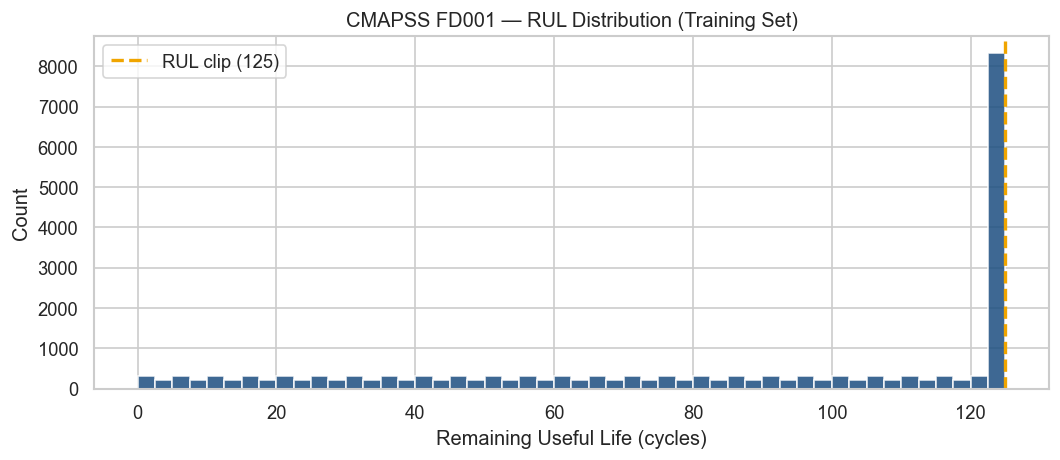

In [5]:
# =============================================================================
# EDA — CMAPSS: RUL DISTRIBUTION
# Purpose: Visualize the distribution of RUL values across all training
#          engines to understand the shape of the prediction target.
# Expected: Right-skewed histogram with a hard cutoff at 125 (RUL clip).
#           Most engines have RUL concentrated between 0-125.
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cmapss_train["rul"], bins=50, color="#1C4E80", edgecolor="white", alpha=0.85)
ax.axvline(x=125, color="#F0A500", linestyle="--", linewidth=2, label="RUL clip (125)")
ax.set_xlabel("Remaining Useful Life (cycles)")
ax.set_ylabel("Count")
ax.set_title("CMAPSS FD001 — RUL Distribution (Training Set)")
ax.legend()
plt.tight_layout()
plt.savefig("images/cmapss_rul_distribution.png", dpi=120)
plt.show()

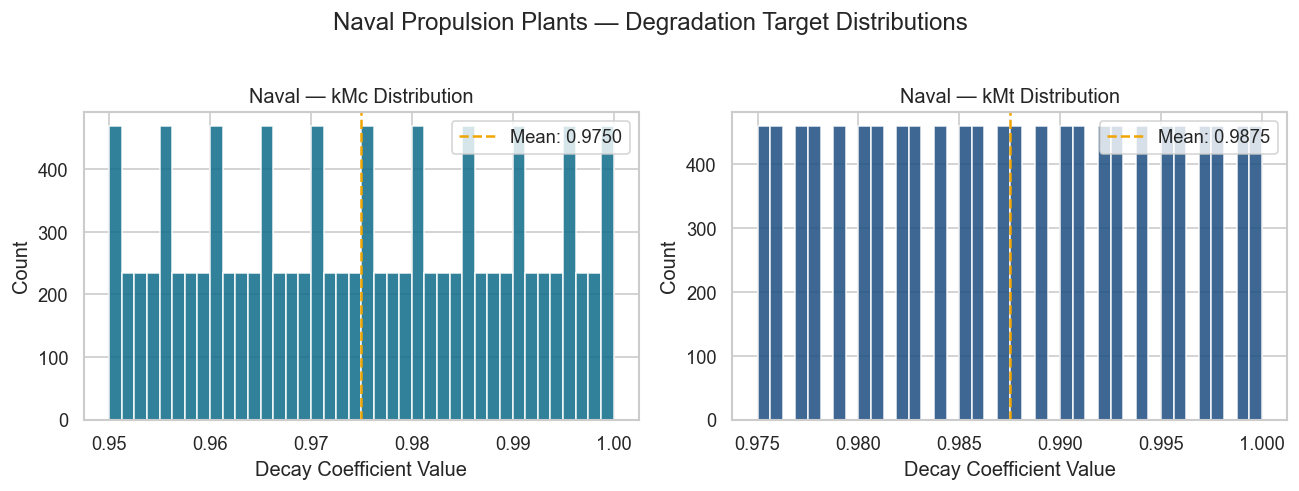

In [6]:
# =============================================================================
# EDA — NAVAL: TARGET DISTRIBUTIONS (kMc and kMt)
# Purpose: Visualize the distribution of both degradation targets side by
#          side to understand their range and spread before modeling.
# Expected: Both targets concentrated near 1.0 (healthy), spreading left
#           toward degraded values. kMt has a narrower range than kMc.
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#0E6B8A", "#1C4E80"]

for ax, col, color in zip(axes, naval_y.columns, colors):
    ax.hist(naval_y[col], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Naval — {col} Distribution")
    ax.set_xlabel("Decay Coefficient Value")
    ax.set_ylabel("Count")
    ax.axvline(naval_y[col].mean(), color="#F0A500", linestyle="--",
               linewidth=1.5, label=f"Mean: {naval_y[col].mean():.4f}")
    ax.legend()

plt.suptitle("Naval Propulsion Plants — Degradation Target Distributions", y=1.02)
plt.tight_layout()
plt.savefig("images/naval_target_distributions.png", dpi=120)
plt.show()

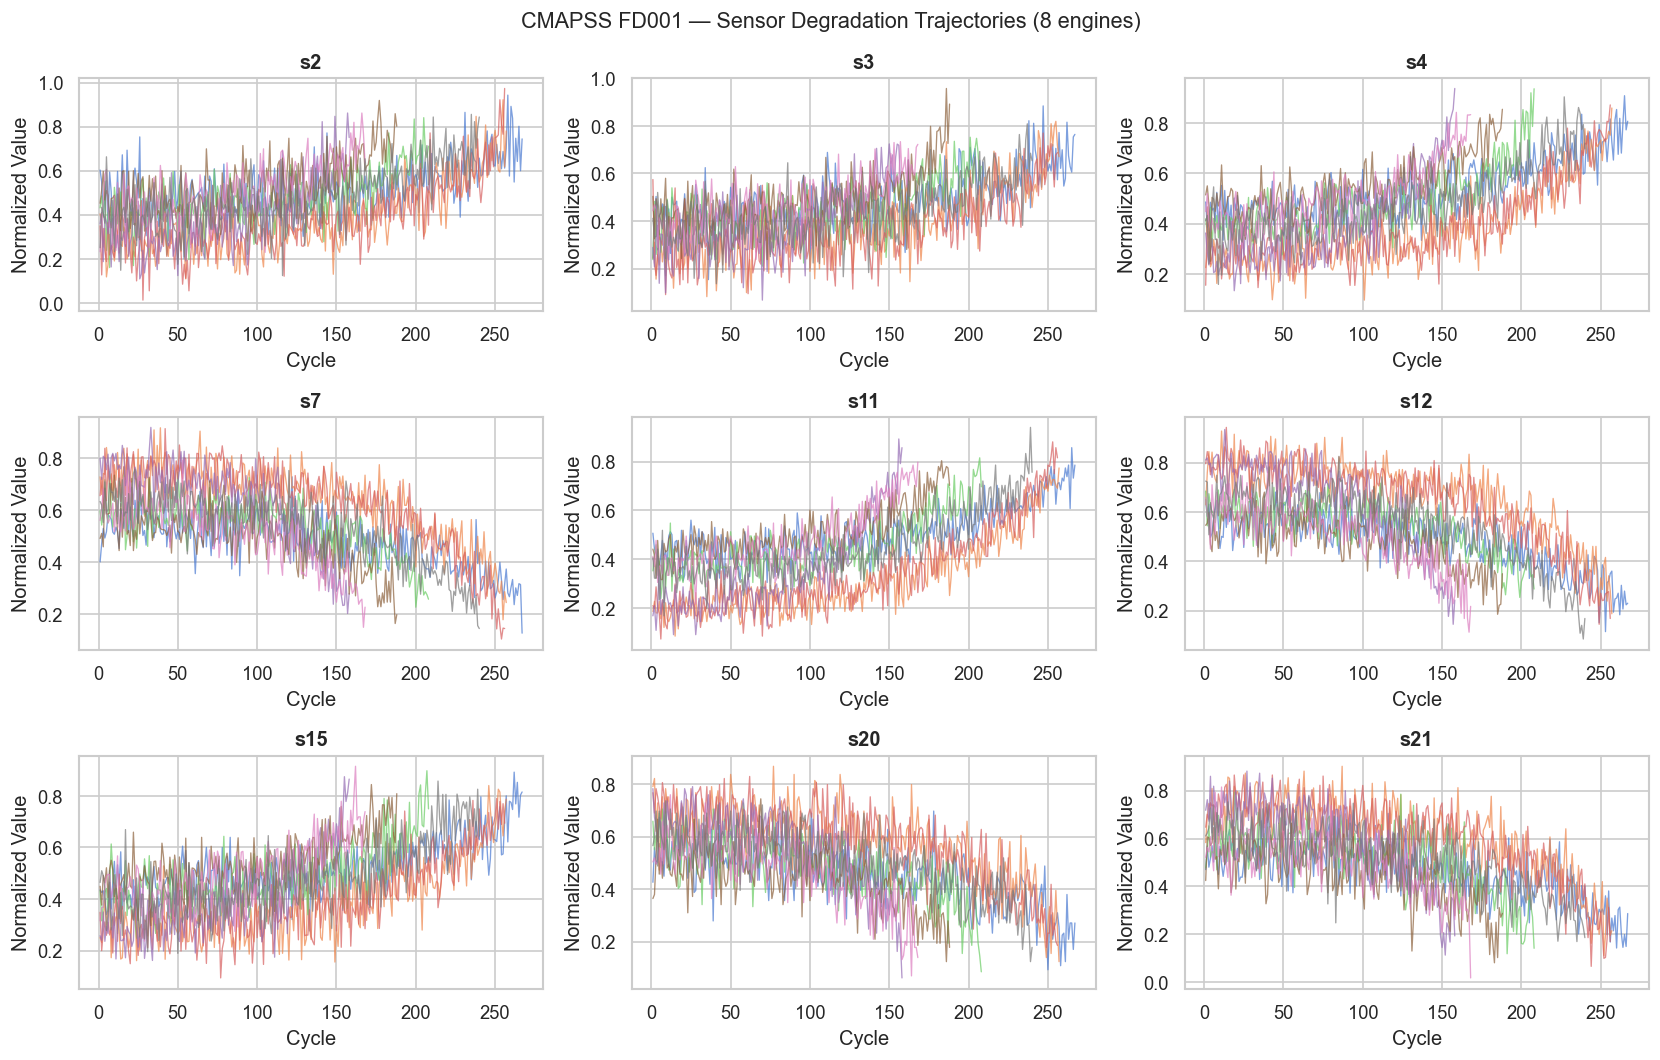

In [7]:
# =============================================================================
# EDA — CMAPSS: SENSOR DEGRADATION TRAJECTORIES
# Purpose: Plot sensor readings over time for a sample of engines to visually
#          confirm which sensors show consistent degradation trends approaching
#          end of life. Each line represents one engine.
# Expected: Informative sensors (s2, s3, s4, s7, s11, s12) show clear
#           directional trends. Flat lines indicate low-signal sensors.
# =============================================================================

np.random.seed(RANDOM_SEED)
sample_engines = np.random.choice(cmapss_train["unit_id"].unique(), size=8, replace=False)
sensors = ["s2", "s3", "s4", "s7", "s11", "s12", "s15", "s20", "s21"]

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, sensor in enumerate(sensors):
    ax = axes[idx]
    for eid in sample_engines:
        engine = cmapss_train[cmapss_train["unit_id"] == eid].sort_values("cycle")
        ax.plot(engine["cycle"], engine[sensor], linewidth=0.8, alpha=0.7)
    ax.set_title(sensor, fontweight="bold")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Normalized Value")

fig.suptitle("CMAPSS FD001 — Sensor Degradation Trajectories (8 engines)", fontsize=13)
plt.tight_layout()
plt.savefig("images/cmapss_degradation_trajectories.png", dpi=120)
plt.show()

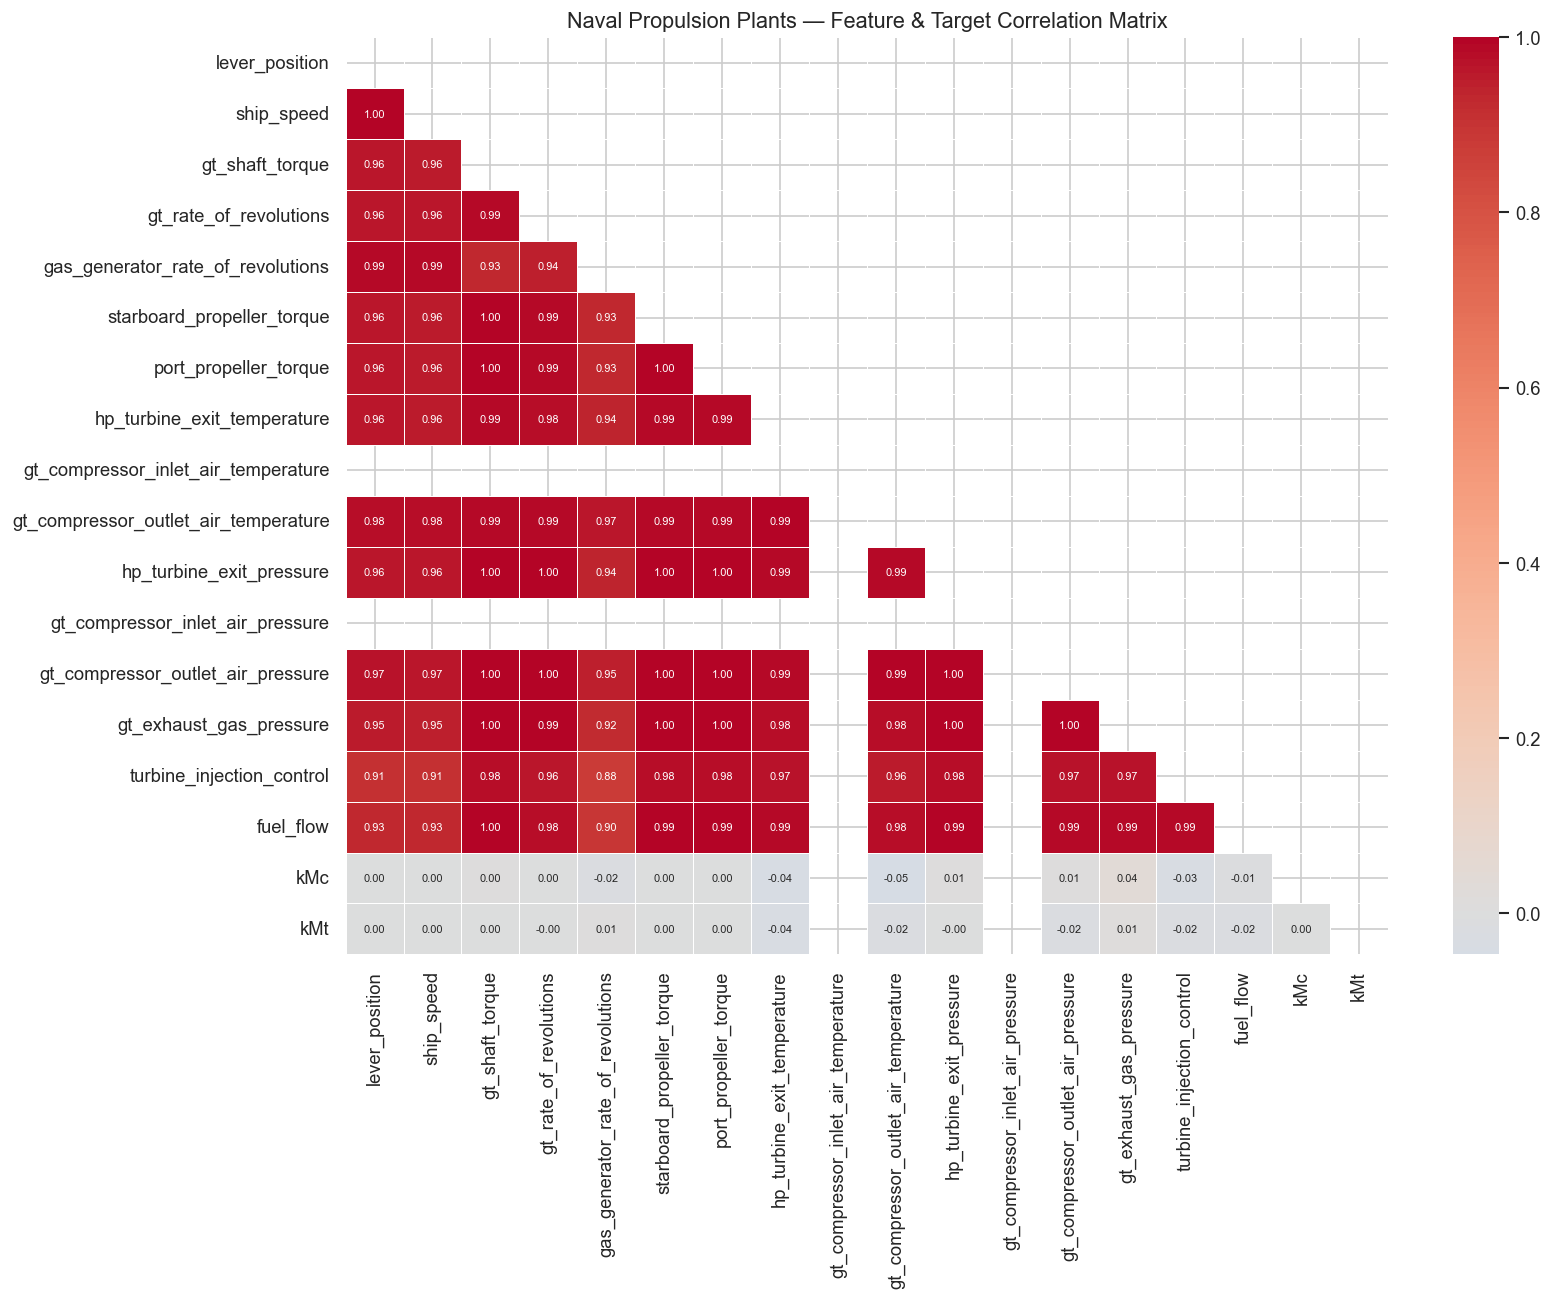

In [8]:
# =============================================================================
# EDA — NAVAL: CORRELATION MATRIX
# Purpose: Identify multicollinearity between features and find which sensors
#          correlate most strongly with kMc and kMt degradation targets.
# Expected: Some temperature/pressure pairs will be highly correlated.
#           kMc and kMt should show strong correlations with compressor
#           and turbine sensor readings respectively.
# =============================================================================

naval_combined = pd.concat([naval_x, naval_y], axis=1)
corr = naval_combined.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    ax=ax,
    annot_kws={"size": 6.5},
)
ax.set_title("Naval Propulsion Plants — Feature & Target Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.savefig("images/naval_correlation_matrix.png", dpi=120)
plt.show()

FD001 — engines: 100  mean life: 206  min: 128  max: 362
FD002 — engines: 260  mean life: 207  min: 128  max: 378
FD003 — engines: 100  mean life: 247  min: 145  max: 525
FD004 — engines: 249  mean life: 246  min: 128  max: 543


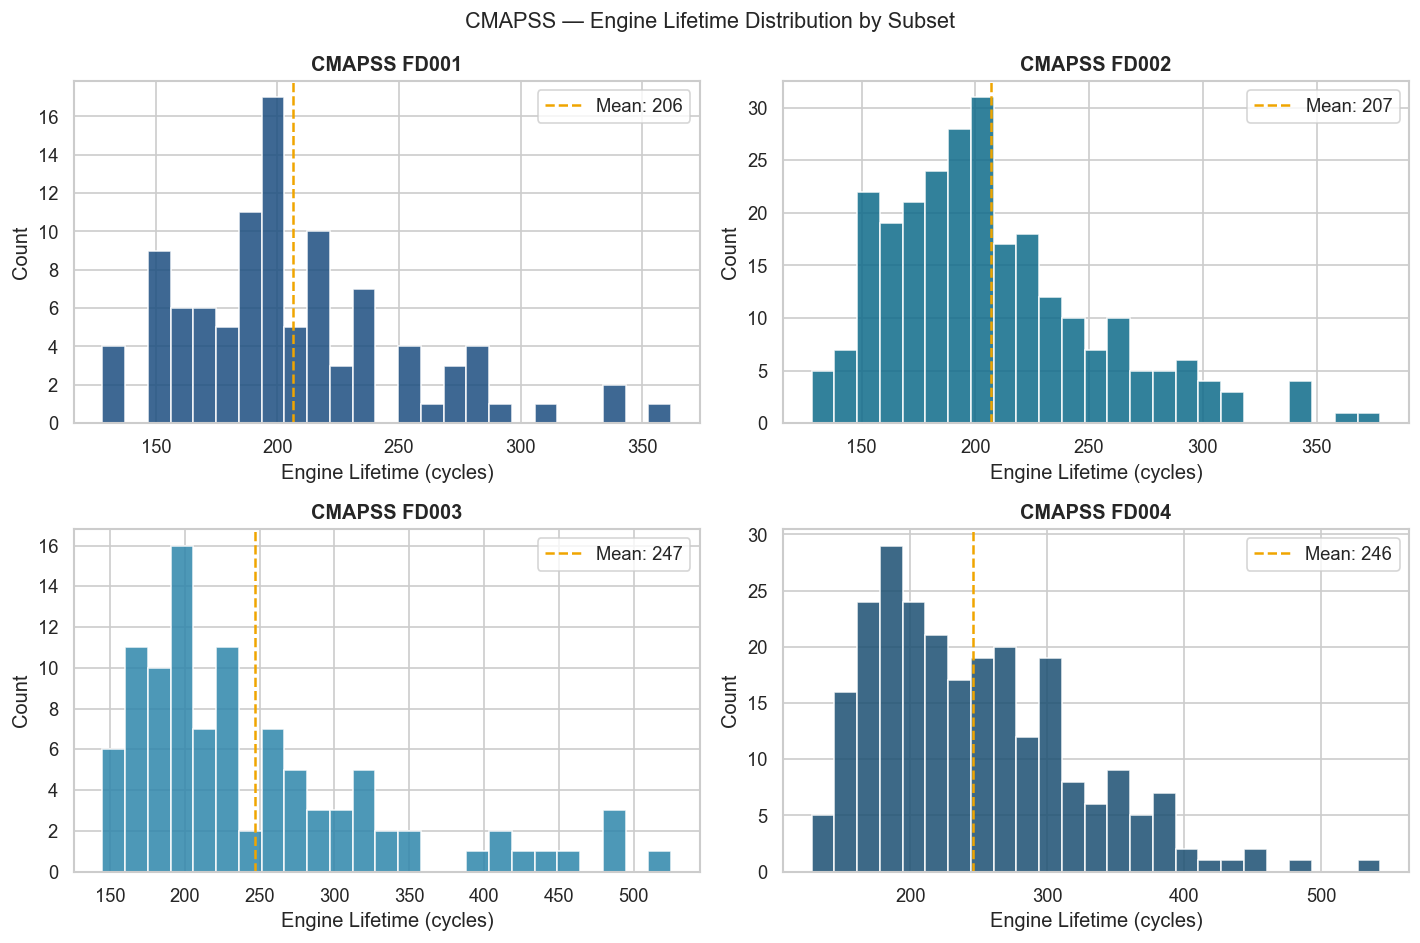

In [9]:
# =============================================================================
# EDA — CMAPSS: ENGINE LIFETIME DISTRIBUTION ACROSS ALL 4 SUBSETS
# Purpose: Compare the distribution of engine lifetimes (total cycles before
#          failure) across FD001-FD004 to understand how dataset complexity
#          increases across subsets.
# Expected: FD001 and FD002 have similar lifetime ranges. FD003 and FD004
#           introduce more variability due to multiple operating conditions
#           and fault modes.
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = ["#1C4E80", "#0E6B8A", "#2E86AB", "#1B4F72"]

for idx, subset in enumerate(["FD001", "FD002", "FD003", "FD004"]):
    train_df, _ = load_cmapss(subset=subset, raw_dir=CMAPSS_DIR)
    lifetimes = train_df.groupby("unit_id")["cycle"].max()

    ax = axes[idx]
    ax.hist(lifetimes, bins=25, color=colors[idx], edgecolor="white", alpha=0.85)
    ax.axvline(lifetimes.mean(), color="#F0A500", linestyle="--",
               linewidth=1.5, label=f"Mean: {lifetimes.mean():.0f}")
    ax.set_title(f"CMAPSS {subset}", fontweight="bold")
    ax.set_xlabel("Engine Lifetime (cycles)")
    ax.set_ylabel("Count")
    ax.legend()
    print(f"{subset} — engines: {len(lifetimes)}  "
          f"mean life: {lifetimes.mean():.0f}  "
          f"min: {lifetimes.min()}  max: {lifetimes.max()}")

fig.suptitle("CMAPSS — Engine Lifetime Distribution by Subset", fontsize=13)
plt.tight_layout()
plt.savefig("images/cmapss_engine_lifetimes.png", dpi=120)
plt.show()

## EDA Summary & Findings

### CMAPSS (Aerospace Domain)

**Dataset Structure**
FD001 contains 100 engines with an average lifetime of 206 cycles (range: 128–362).
FD003/FD004 introduce longer and more variable lifetimes (up to 525+ cycles) due to
multiple operating conditions and fault modes — making them progressively harder
prediction tasks. FD002/FD004 include 260 and 249 engines respectively, providing
more training data but at the cost of increased operating condition variability.

**RUL Distribution**
The piecewise linear RUL clip at 125 cycles is working as intended; the large spike
at 125 represents all early-life cycles being capped, reflecting the assumption that
engines far from failure are equally "healthy" regardless of exact cycle count. The
flat distribution from 0–124 means the training set has balanced coverage across all
degradation stages, which is favorable for model learning.

**Sensor Degradation Signals**
Clear degradation trends are visible in:
- **s11** (Fan outlet static pressure) and **s12** (Corrected fan speed) — strongest
  and most consistent directional trends across all 8 sampled engines. These are the
  primary degradation indicators and should rank as top SHAP features.
- **s7, s20, s21** — moderate decreasing trends approaching end of life.
- **s2, s3, s4, s15** — noisier but still exhibit directional drift.

The high variance between individual engine trajectories is expected and reflects
real-world variability in engine manufacturing tolerances and operational conditions.
This is precisely why sequence models (LSTM, CNN-LSTM) are better suited than
tabular models — they can learn engine-specific degradation patterns over time.

---

### Naval (Naval Domain)

**Dataset Structure**
11,934 steady-state observations from a Navy Frigate CODLAG gas turbine simulator.
Unlike CMAPSS, this is not a time series — each row is an independent operating point.
This fundamental structural difference is a key cross-domain challenge: CMAPSS requires
sequence modeling while Naval is a tabular regression problem.

**Target Distributions**
Both kMc (GT Compressor decay, range 0.95–1.0) and kMt (GT Turbine decay, range
0.975–1.0) follow near-uniform distributions, meaning the simulator sampled evenly
across all degradation states from healthy (1.0) to degraded. This is ideal for
regression; no class imbalance or sparse failure events to worry about.

**Feature Correlations**
The correlation matrix reveals two critical findings:

1. **Severe multicollinearity among operational features** — speed, torque, pressure,
   and temperature sensors form a tightly correlated block (r = 0.93–1.00). This means
   many features carry redundant information. Tree-based models will handle this
   naturally through feature selection; deep learning models may benefit from
   dimensionality reduction or regularization.

2. **Near-zero correlation between all features and both targets** (r ≈ 0.00 to -0.05).
   kMc and kMt degradation cannot be predicted from any single feature in isolation —
   the degradation signal only emerges from the *interaction* between multiple sensor
   readings simultaneously. This is the core justification for using nonlinear models
   (XGBoost, neural networks) over linear regression, and makes the Naval domain a
   genuinely challenging prediction task.

---

### Cross-Domain Implications

| Factor | CMAPSS (Aerospace) | Naval |
|--------|-------------------|-------|
| Data type | Time series (sequential) | Tabular (steady-state) |
| Target | RUL in cycles (0–125) | Decay coefficients (0.95–1.0) |
| Signal clarity | Strong trends visible in 6+ sensors | Near-zero linear correlations |
| Key challenge | Variable engine lifetimes across subsets | Multicollinearity + nonlinear targets |
| Model fit | Sequence models (LSTM, CNN-LSTM) | Nonlinear regressors (XGBoost, MLP) |

These structural differences directly motivate the unified pipeline design: a shared
preprocessing and evaluation framework with domain-specific model configurations.
The fact that the Naval degradation signal is entirely nonlinear while CMAPSS has
clear temporal structure will be a central thread in the cross-domain analysis.